In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from sklearn.metrics import root_mean_squared_error
from darts.timeseries import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.models import TFTModel

/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data Preparation

In [2]:
df = pd.read_csv('electricity.csv', index_col= 'ds', parse_dates=True)
df = df.query('unique_id in ("FR", "BE")')
df

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2016-10-22 00:00:00,BE,70.00,49593.0,57253.0
2016-10-22 01:00:00,BE,37.10,46073.0,51887.0
2016-10-22 02:00:00,BE,37.10,44927.0,51896.0
2016-10-22 03:00:00,BE,44.75,44483.0,48428.0
2016-10-22 04:00:00,BE,37.10,44338.0,46721.0
...,...,...,...,...
2016-12-30 19:00:00,FR,72.04,70329.0,75911.0
2016-12-30 20:00:00,FR,70.60,69121.0,73706.0
2016-12-30 21:00:00,FR,69.59,66647.0,71003.0


In [3]:
df_fr = df.query('unique_id == "FR"').asfreq('h')
df_be = df.query('unique_id == "BE"').asfreq('h')
df = df.reset_index()

Exploratory Data Analysis

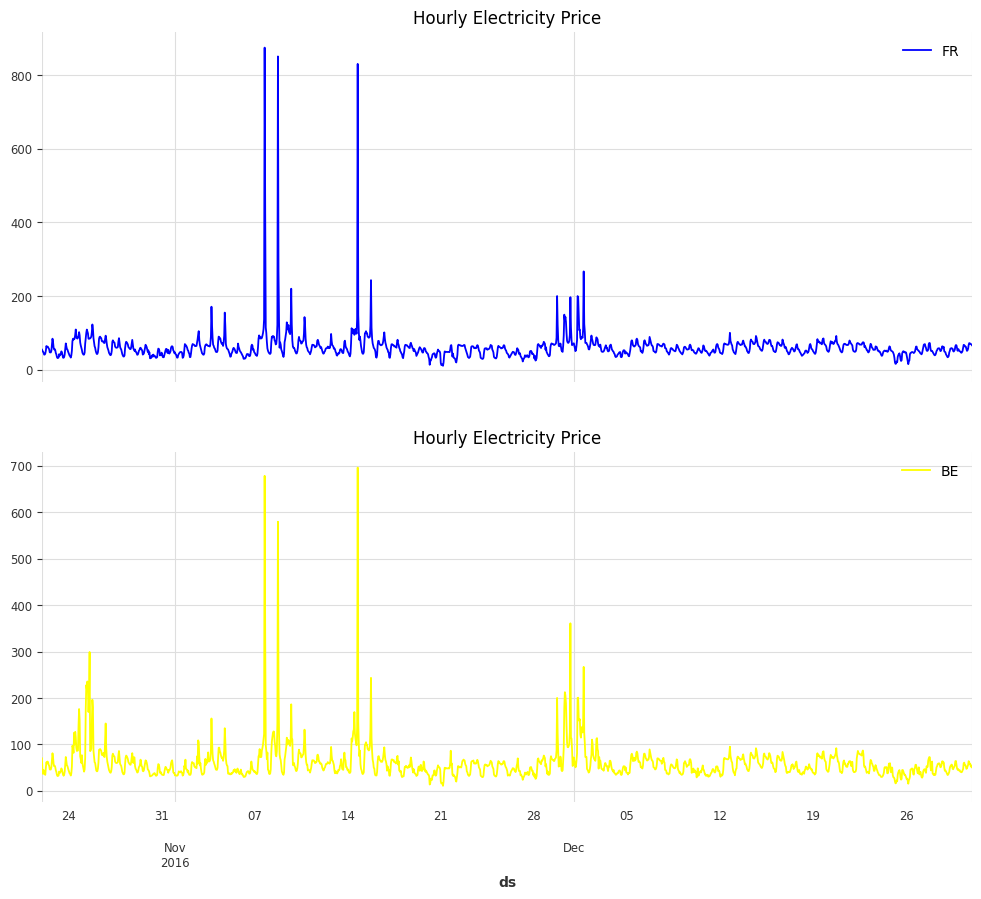

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
df_fr['y'].plot(title='Hourly Electricity Price', color='blue', label ='FR', ax=ax[0])
df_be['y'].plot(title='Hourly Electricity Price', color='yellow', label ='BE', ax=ax[1])

ax[0].legend()
ax[1].legend()

plt.show()

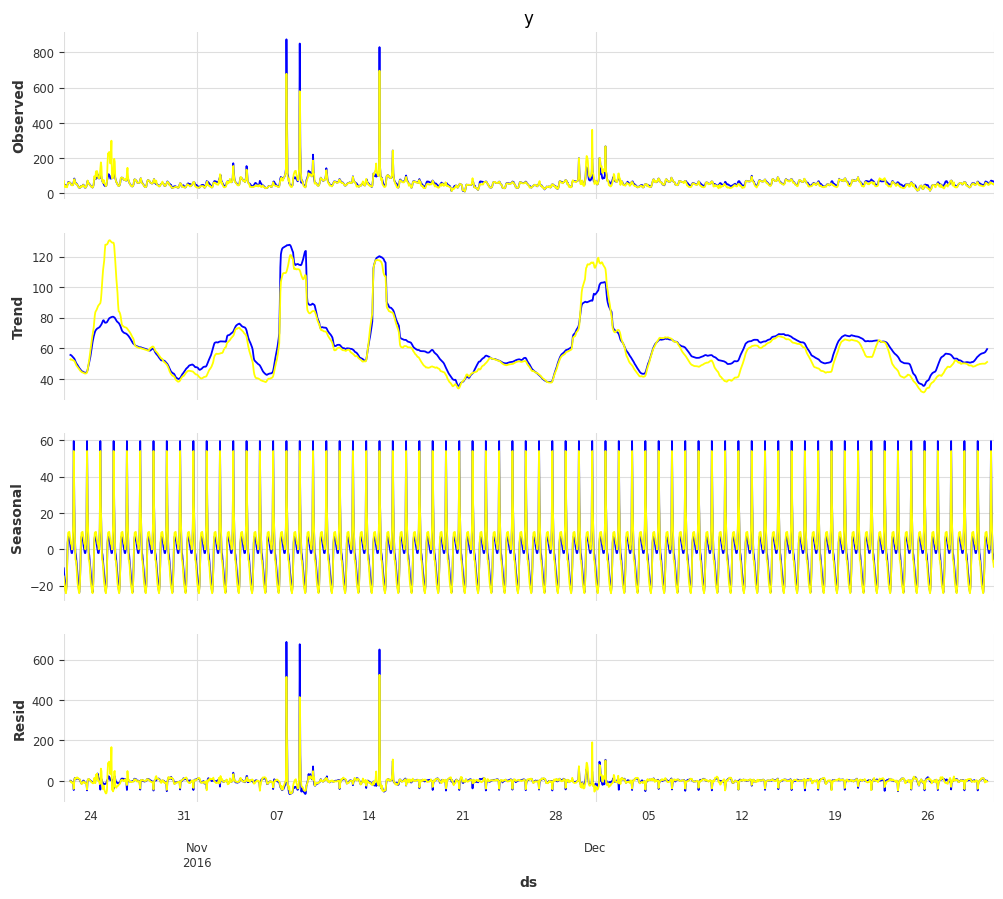

In [5]:
fig, ax = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fr_decompose = seasonal_decompose(df_fr['y'])
be_decompose = seasonal_decompose(df_be['y'])

ax[0].set_title('y')

fr_decompose.observed.plot(ax=ax[0], ylabel='Observed', color='blue', label='FR')
fr_decompose.trend.plot(ax=ax[1], color='blue', ylabel='Trend')
fr_decompose.seasonal.plot(ax=ax[2], color='blue', ylabel='Seasonal')
fr_decompose.resid.plot(ax=ax[3], color='blue', ylabel='Resid')

be_decompose.observed.plot(ax=ax[0], ylabel='Observed', color='yellow', label='BE')
be_decompose.trend.plot(ax=ax[1], ylabel='Trend', color='yellow')
be_decompose.seasonal.plot(ax=ax[2], ylabel='Seasonal', color='yellow')
be_decompose.resid.plot(ax=ax[3], ylabel='Resid', color='yellow')

for i in range(4):
    ax[i].grid(True)


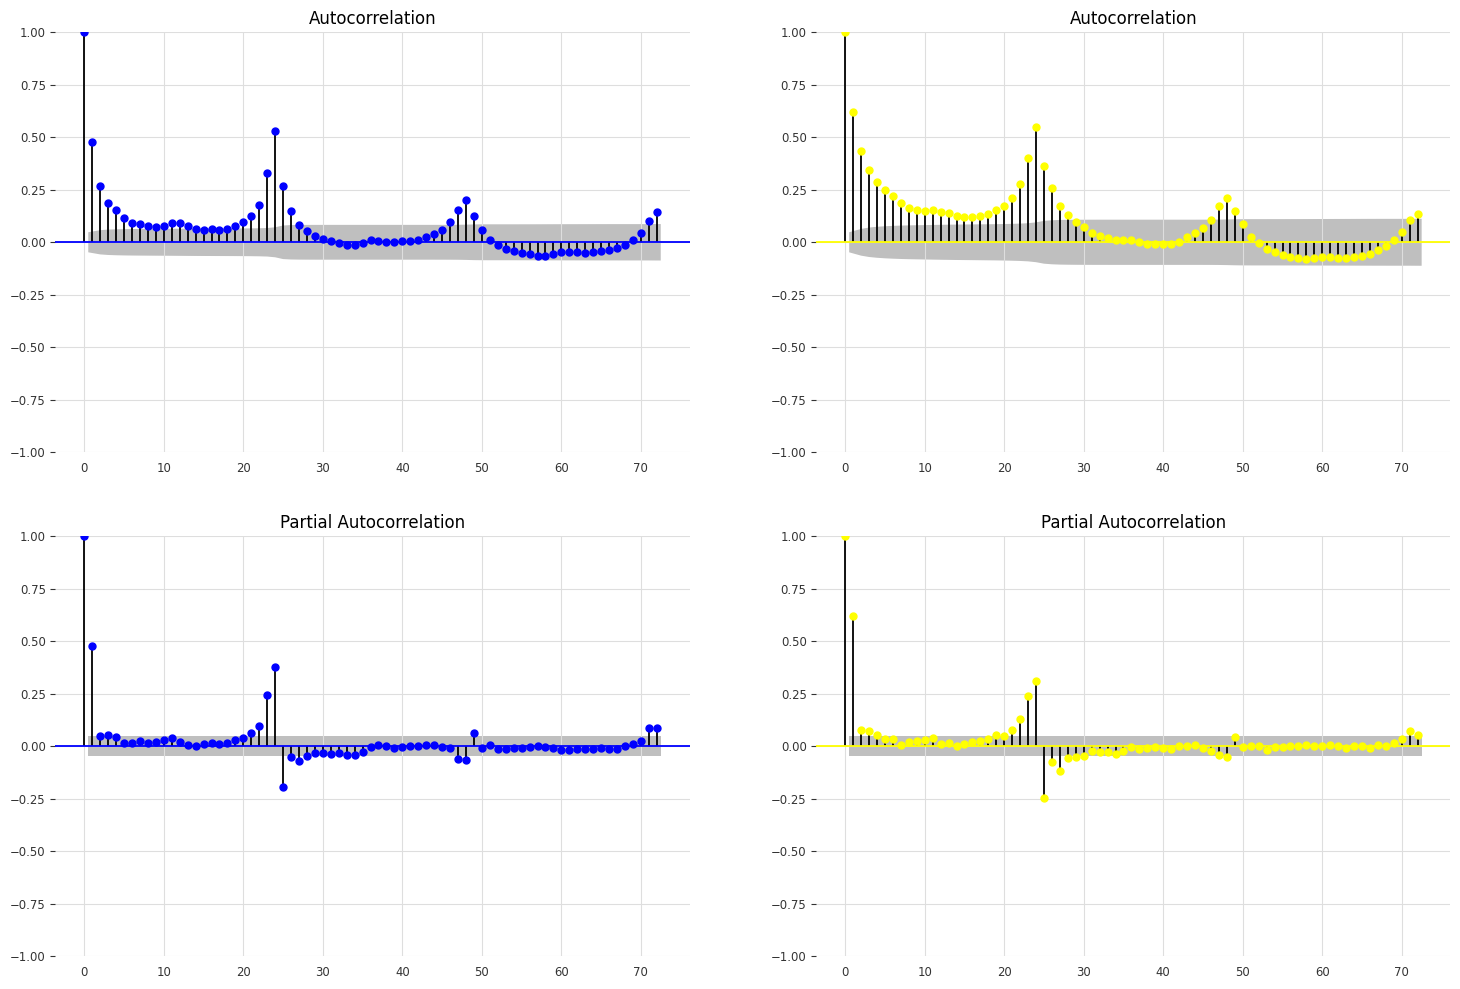

In [6]:
fig, ax = plt.subplots(2, 2, figsize = (18, 12))

plot_acf(df_fr['y'], lags=72, ax=ax[0, 0], color='blue')
plot_pacf(df_fr['y'], lags=72, ax=ax[1, 0], color='blue')
plot_acf(df_be['y'], lags=72, ax=ax[0, 1], color='yellow')
plot_pacf(df_be['y'], lags=72, ax=ax[1, 1], color='yellow')

plt.show()


Prepare data

In [7]:
def encode_year(idx):
    (idx.year - 2000) / 50

add_encoders = {
    'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week','month']},
    'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week','month']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom': {'past': [encode_year], 'future': [encode_year]},
    'transformer': Scaler(),
    'tz': 'CET'
}

In [8]:
df['unique_id'] = df['unique_id'].astype('category').cat.codes

Time Series, Time and Static Covariates

In [13]:
# Function to encode the year as a normalized value
def encode_year(idx):
  return (idx.year - 2000) / 50

# Set up the add_encoders dictionary to specify how different time-related encoders and transformers should be applied
add_encoders = {
    'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week','month']},
    'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week','month']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom': {'past': [encode_year], 'future': [encode_year]},
    'transformer': Scaler(),
    'tz': 'CET'
}

In [14]:
# Convert the 'unique_id' column to a categorical variable and then to numerical codes
df['unique_id'] = df['unique_id'].astype('category').cat.codes
df.head()

,ds,unique_id,y,Exogenous1,Exogenous2
0,2016-10-22 00:00:00,0,70.00,49593.0,57253.0
1,2016-10-22 01:00:00,0,37.10,46073.0,51887.0
2,2016-10-22 02:00:00,0,37.10,44927.0,51896.0
3,2016-10-22 03:00:00,0,44.75,44483.0,48428.0
4,2016-10-22 04:00:00,0,37.10,44338.0,46721.0


In [15]:
# Set up the variables
TIME_COL = "ds"
TARGET = "y"
GROUP_COL = ["unique_id"]
FREQ = "h" # hourly data

In [18]:
series = TimeSeries.from_group_dataframe(
    df=df,                # DataFrame containing the data
    time_col=TIME_COL,    # Column representing the time dimension
    group_cols=GROUP_COL, # Column(s) representing the group or series identifier(s)
    value_cols=TARGET,    # Column representing the target variable (the value to forecast)
    freq=FREQ             # Frequency of the data
)

Past Covariates

In [17]:
COVARIATES = ["Exogenous1", "Exogenous2"]

past_covariates = TimeSeries.from_group_dataframe(
    df=df,                # DataFrame containing the data
    time_col=TIME_COL,    # Column representing the time dimension
    group_cols=GROUP_COL, # Column(s) representing the group or series identifier(s)
    value_cols=COVARIATES, # Columns representing the exogenous variables (past covariates)
    freq=FREQ             # Frequency of the data
)

Future Covariates

In [18]:
# Convert the 'unique_id' column to a categorical variable and then to numerical codes
future_df = pd.read_csv('electricity-future.csv')
future_df = future_df[future_df['unique_id'].isin(['FR', 'BE'])]
future_df['unique_id'] = future_df['unique_id'].astype('category').cat.codes
future_df.head()

,unique_id,ds,Exogenous1,Exogenous2
0,0,12/31/2016 0:00,64108.0,70318.0
1,0,12/31/2016 1:00,62492.0,67898.0
2,0,12/31/2016 2:00,61571.0,68379.0
3,0,12/31/2016 3:00,60381.0,64972.0
4,0,12/31/2016 4:00,60298.0,62900.0


In [19]:
# Concatenate the original DataFrame (excluding the target 'y' column) with the future data
df_full = pd.concat([df.drop(columns = ['y']), future_df])
df_full.head()

,ds,unique_id,Exogenous1,Exogenous2
0,2016-10-22 00:00:00,0,49593.0,57253.0
1,2016-10-22 01:00:00,0,46073.0,51887.0
2,2016-10-22 02:00:00,0,44927.0,51896.0
3,2016-10-22 03:00:00,0,44483.0,48428.0
4,2016-10-22 04:00:00,0,44338.0,46721.0


In [20]:
# Create the future covariates time series instance from the full DataFrame using group-based columns
future_covariates = TimeSeries.from_group_dataframe(
    df=df_full,           # Full DataFrame containing both current and future data
    time_col=TIME_COL,    # Column representing the time dimension
    group_cols=GROUP_COL, # Column(s) representing the group or series identifier(s)
    value_cols=COVARIATES, # Columns representing the exogenous variables (future covariates)
    freq=FREQ             # Frequency of the data
)

In [21]:
# Scaling the past covariates
scaler_y = Scaler()
scaler_covariates = Scaler()
y_transformed = scaler_y.fit_transform(series)
past_covariates_transformed = scaler_covariates.fit_transform(past_covariates)
future_covariates_transformed = scaler_covariates.fit_transform(future_covariates)

TFT Model

In [22]:
forecasting_horizon = 24

In [24]:
model = TFTModel(
    input_chunk_length=96,
    output_chunk_length=forecasting_horizon,
    hidden_size=16,
    lstm_layers=2,
    num_attention_heads=4,
    dropout=0.1,
    batch_size=64,
    n_epochs=10,
    use_static_covariates=True,
    add_encoders = add_encoders,
    pl_trainer_kwargs={"accelerator": "cpu"}
)

model.fit(y_transformed,
          past_covariates=past_covariates_transformed,
          future_covariates=future_covariates_transformed)

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 528    | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 17.2 K | train
5  | decoder_vsn                       | _Vari

Epoch 9: 100%|██████████| 49/49 [00:08<00:00,  5.88it/s, train_loss=0.0856]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 49/49 [00:08<00:00,  5.88it/s, train_loss=0.0856]


TFTModel(output_chunk_shift=0, hidden_size=16, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=96, output_chunk_length=24, batch_size=64, n_epochs=10, add_encoders={'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x7f28ca4d71a0>], 'future': [<function encode_year at 0x7f28ca4d71a0>]}, 'transformer': Scaler, 'tz': 'CET'}, pl_trainer_kwargs={'accelerator': 'cpu'})

In [25]:
cv = model.historical_forecasts(series = y_transformed,
                                past_covariates = past_covariates_transformed,
                                future_covariates = future_covariates_transformed,
                                start = 1680 - 240,
                                forecast_horizon = 24,
                                stride = 24,
                                retrain = True,
                                last_points_only = False)

`enable_optimization=True` is ignored because `retrain` is not `False` or `0`. To hide this warning, set `show_warnings=False` or `enable_optimization=False`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork   

Epoch 9: 100%|██████████| 21/21 [00:03<00:00,  5.87it/s, train_loss=0.170]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 21/21 [00:03<00:00,  5.87it/s, train_loss=0.170]

GPU available: True (cuda), used: False


...

Epoch 9: 100%|██████████| 25/25 [00:04<00:00,  6.02it/s, train_loss=0.096] 

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 25/25 [00:04<00:00,  6.02it/s, train_loss=0.096]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/home/salgado/scripts/time_series/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


In [26]:
rmse_cv = []

for j in range(len(cv[0])):
    period_predictions = []

    for i in range(2):
        period_predictions.append(cv[i][j])

    period_predictions_unscaled = scaler_y.inverse_transform(period_predictions)

    series_rmse = []
    for i in range(2):
        predictions = period_predictions_unscaled[i]
        predictions_df = predictions.pd_dataframe()

        start = predictions_df.index.min()
        end = predictions_df.index.max()

        actuals = df.query('ds >= @start and ds <= @end and unique_id == @i')
        actuals = actuals.set_index('ds')['y']

        error_cv = root_mean_squared_error(actuals, predictions_df['y'])
        series_rmse.append(error_cv)
    
    rmse_cv.append(np.mean(series_rmse))

print(rmse_cv)
print(np.mean(rmse_cv))

[28.31485678348053, 41.13273023185121, 20.84232712764662, 28.524742003796103, 30.628848648836744, 51.137109034161384, 42.234363050684, 29.208161708593096, 32.36445209708077, 23.815033358269062]
32.82026240443995


Parameter Tuning

In [ ]:
from sklearn.model_selection import ParameterSampler

param_grid = {
    'input_chunk_length': [48, 96],
    'output_chunk_length': [24],
    'hidden_size': [12, 16, 20],
    'num_attention_heads': [2, 4, 6],
    'dropout': [0.1],
    'batch_size': [32, 64],
    'lstm_layers': [2, 4],
    'n_epochs': [20]
} 

In [28]:
n_iter = 5

param_list = list(ParameterSampler(param_grid,
                                   n_iter=n_iter*2,
                                   random_state=42))

param_list1 = param_list[:n_iter]
param_list2 = param_list[n_iter:]

In [29]:
fixed_params = {
    'use_static_covariates': True,
    'add_encoders': add_encoders,
    'pl_trainer_kwargs': {'accelerator': 'cpu'}
}

for params in param_list1:
    params.update(fixed_params)

for params in param_list2:
    params.update(fixed_params)

In [ ]:
rmse1 = []

for n, params in enumerate(param_list1):

    print(f'\n\n\n\n\n\n\nTraining set {n}\n\n\n\n\n\n\n')
    
    model = TFTModel(**params)

    cv = model.historical_forecasts(series = y_transformed,
                                    past_covariates = past_covariates_transformed,
                                    future_covariates = future_covariates_transformed,
                                    start = 1680 - 240,
                                    forecast_horizon = 24,
                                    stride = 24,
                                    retrain = True,
                                    last_points_only = False)
    
    rmse_cv = []

    for j in range(len(cv[0])):

        period_predictions = []

        for i in range(2):
            period_predictions.append(cv[i][j])

        period_predictions_unscaled = scaler_y.inverse_transform(period_predictions)

        series_rmse = []

        for i in range(2):
            predictions = period_predictions_unscaled[i]
            predictions_df = predictions.pd_dataframe()

            start = predictions_df.index.min()
            end = predictions_df.index.max()

            actuals = df.query('ds >= @start and ds <= @end and unique_id == @i')
            actuals = actuals.set_index('ds')['y']

            error_cv = root_mean_squared_error(actuals, predictions_df['y'])
            series_rmse.append(error_cv)
        
        rmse_cv.append(np.mean(series_rmse))
    
    mean_rmse = np.mean(rmse_cv)
    rmse1.append(mean_rmse)

Could only train first batch. Training took > 3hrs.

In [39]:
rmse1

[21.41199073274975,
 23.291871770039066,
 16.103367628536397,
 18.06636786885631,
 14.935677703720803]

In [48]:
results_df = pd.DataFrame(param_list1).iloc[:,:8]
results_df['rmse'] = rmse1
results_df

,output_chunk_length,num_attention_heads,n_epochs,lstm_layers,input_chunk_length,hidden_size,dropout,batch_size,rmse
0,24,4,20,4,48,12,0.1,32,21.411991
1,24,6,20,2,48,20,0.1,64,23.291872
2,24,2,20,2,96,16,0.1,32,16.103368
3,24,2,20,2,48,12,0.1,32,18.066368
4,24,4,20,4,48,20,0.1,32,14.935678


In [57]:
best_params = results_df.query('rmse =='+str(min(rmse1))).drop(columns='rmse')
best_params_dict= best_params.squeeze().to_dict()

Predictions

In [58]:
int_params = ['input_chunk_length', 'output_chunk_length',
              'hidden_size', 'num_attention_heads', 'batch_size',
              'lstm_layers', 'n_epochs']

# Convert specified float parameters to integers
for key in int_params:
  best_params_dict[key] = int(best_params_dict[key])

In [59]:
tuned_model = TFTModel(**best_params_dict)

# Fit the tuned model
tuned_model.fit(y_transformed,
                past_covariates = past_covariates_transformed,
                future_covariates = future_covariates_transformed)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 620    | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 3.5 K  | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 1.3 K  | train
6  | static_context_grn                | _GatedResidualNetwork            | 1.7 K  | train
7  | static_cont

Epoch 19: 100%|██████████| 101/101 [00:04<00:00, 23.28it/s, train_loss=0.0623]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 101/101 [00:04<00:00, 23.28it/s, train_loss=0.0623]


TFTModel(output_chunk_shift=0, hidden_size=20, lstm_layers=4, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, output_chunk_length=24, n_epochs=20, input_chunk_length=48, batch_size=32)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 58.13it/s]


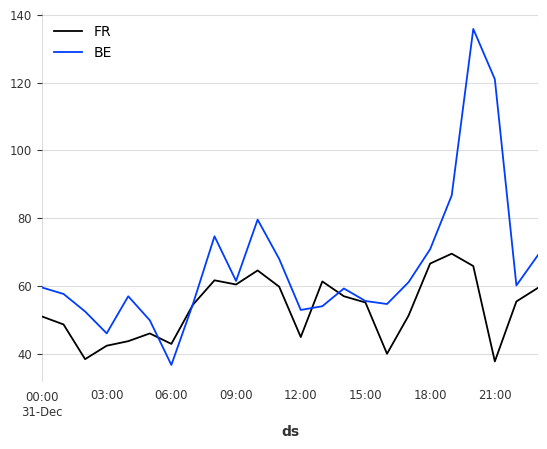

In [82]:
predictions = tuned_model.predict(n=forecasting_horizon,
                         series = y_transformed,
                         past_covariates = past_covariates_transformed,
                         future_covariates = future_covariates_transformed)

unscaled_predictions = scaler_y.inverse_transform(predictions)

dataframes = [ts.pd_dataframe() for ts in unscaled_predictions]

fig, ax = plt.subplots()
dataframes[0].plot(y='y', label='FR', ax=ax)
dataframes[1].plot(y='y', label='BE', ax=ax)

ax.legend()  # Ensure legend is shown
plt.show()